<a href="https://colab.research.google.com/github/HarshitMendiratta-18/Duality-ai/blob/main/DualityAI_Hackathon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
# Is cell ko run karte hi nayi 'train_segmentation_colab.py' ban jayegi
content = """
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torch.optim as optim
import torchvision.transforms as transforms
from PIL import Image
import cv2
import os
from tqdm import tqdm

# Mapping from raw pixel values to new class IDs
value_map = {0: 0, 100: 1, 200: 2, 300: 3, 500: 4, 550: 5, 700: 6, 800: 7, 7100: 8, 10000: 9}
n_classes = len(value_map)

def convert_mask(mask):
    arr = np.array(mask)
    new_arr = np.zeros_like(arr, dtype=np.uint8)
    for raw_value, new_value in value_map.items():
        new_arr[arr == raw_value] = new_value
    return Image.fromarray(new_arr)

class MaskDataset(Dataset):
    def __init__(self, data_dir, transform=None, mask_transform=None):
        self.image_dir = os.path.join(data_dir, 'Color_Images')
        self.masks_dir = os.path.join(data_dir, 'Segmentation')
        self.transform = transform
        self.mask_transform = mask_transform
        self.data_ids = os.listdir(self.image_dir)
    def __len__(self): return len(self.data_ids)
    def __getitem__(self, idx):
        data_id = self.data_ids[idx]
        image = Image.open(os.path.join(self.image_dir, data_id)).convert("RGB")
        mask = convert_mask(Image.open(os.path.join(self.masks_dir, data_id)))
        if self.transform:
            image = self.transform(image)
            mask = self.mask_transform(mask) * 255
        return image, mask

class SegmentationHeadConvNeXt(nn.Module):
    def __init__(self, in_channels, out_channels, tokenW, tokenH):
        super().__init__()
        self.H, self.W = tokenH, tokenW
        self.stem = nn.Sequential(nn.Conv2d(in_channels, 128, kernel_size=7, padding=3), nn.GELU())
        self.block = nn.Sequential(nn.Conv2d(128, 128, kernel_size=7, padding=3, groups=128), nn.GELU(), nn.Conv2d(128, 128, kernel_size=1), nn.GELU())
        self.classifier = nn.Conv2d(128, out_channels, 1)
    def forward(self, x):
        B, N, C = x.shape
        x = x.reshape(B, self.H, self.W, C).permute(0, 3, 1, 2)
        return self.classifier(self.block(self.stem(x)))

def main():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    h, w = 266, 476 # Pre-calculated for batch_size 2
    n_epochs = 50

    transform = transforms.Compose([
        transforms.Resize((h, w)),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    mask_transform = transforms.Compose([transforms.Resize((h, w)), transforms.ToTensor()])

    train_dir = "/content/Offroad_Segmentation_Training_Dataset/train"
    val_dir = "/content/Offroad_Segmentation_Training_Dataset/val"

    train_loader = DataLoader(MaskDataset(train_dir, transform, mask_transform), batch_size=2, shuffle=True)
    val_loader = DataLoader(MaskDataset(val_dir, transform, mask_transform), batch_size=2, shuffle=False)

    backbone = torch.hub.load("facebookresearch/dinov2", "dinov2_vits14").to(device).eval()
    classifier = SegmentationHeadConvNeXt(384, n_classes, w//14, h//14).to(device)

    weights = torch.tensor([1.0, 1.5, 1.5, 1.2, 2.0, 2.5, 5.0, 5.0, 1.0, 0.5]).to(device)
    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = optim.AdamW(classifier.parameters(), lr=1e-4)

    for epoch in range(n_epochs):
        classifier.train()
        total_loss = 0
        for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{n_epochs}"):
            imgs, labels = imgs.to(device), labels.to(device).squeeze(1).long()
            with torch.no_grad():
                features = backbone.forward_features(imgs)["x_norm_patchtokens"]
            outputs = F.interpolate(classifier(features), size=imgs.shape[2:], mode="bilinear")
            loss = criterion(outputs, labels)
            loss.backward(); optimizer.step(); optimizer.zero_grad()
            total_loss += loss.item()
        print(f"Epoch {epoch+1} Loss: {total_loss/len(train_loader):.4f}")

    torch.save(classifier.state_dict(), "segmentation_model_best.pth")
    print("✅ Training Complete! Model Saved.")

if __name__ == "__main__":
    main()
"""

with open('train_segmentation_colab.py', 'w') as f:
    f.write(content)

print("🚀 Script Created Successfully!")

🚀 Script Created Successfully!


In [25]:
!python train_segmentation_colab.py

Using device: cuda
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")
Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth
100% 84.2M/84.2M [00:00<00:00, 283MB/s]
Epoch 1/50: 100% 1429/1429 [03:02<00:00,  7.84it/s]
Epoch 1 Loss: 1.2660
Epoch 2/50: 100% 1429/1429 [02:54<00:00,  8.21i

In [26]:
import matplotlib.pyplot as plt

# Model ko test mode mein dalo
classifier.eval()
imgs, labels = next(iter(val_loader))

with torch.no_grad():
    features = backbone.forward_features(imgs.to(device))["x_norm_patchtokens"]
    outputs = F.interpolate(classifier(features), size=imgs.shape[2:], mode="bilinear")
    preds = torch.argmax(outputs, dim=1).cpu()

# Plotting results
plt.figure(figsize=(15, 6))
plt.subplot(1, 3, 1); plt.imshow(imgs[0].permute(1, 2, 0).cpu().numpy()); plt.title("Original Offroad Image")
plt.subplot(1, 3, 2); plt.imshow(labels[0].squeeze().numpy(), cmap='tab10'); plt.title("Actual Ground Truth")
plt.subplot(1, 3, 3); plt.imshow(preds[0].numpy(), cmap='tab10'); plt.title("Model's Prediction")
plt.show()

NameError: name 'classifier' is not defined

In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from PIL import Image
import os

# 1. Classes aur Model structure define kar rahe hain (Same as training)
class SegmentationHeadConvNeXt(nn.Module):
    def __init__(self, in_channels, out_channels, tokenW, tokenH):
        super().__init__()
        self.H, self.W = tokenH, tokenW
        self.stem = nn.Sequential(nn.Conv2d(in_channels, 128, kernel_size=7, padding=3), nn.GELU())
        self.block = nn.Sequential(nn.Conv2d(128, 128, kernel_size=7, padding=3, groups=128), nn.GELU(), nn.Conv2d(128, 128, kernel_size=1), nn.GELU())
        self.classifier = nn.Conv2d(128, out_channels, 1)
    def forward(self, x):
        B, N, C = x.shape
        x = x.reshape(B, self.H, self.W, C).permute(0, 3, 1, 2)
        return self.classifier(self.block(self.stem(x)))

# 2. Setup Variables
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
h, w = 266, 476
n_classes = 10

# 3. Backbone aur Classifier ko load kar rahe hain
backbone = torch.hub.load("facebookresearch/dinov2", "dinov2_vits14").to(device).eval()
classifier = SegmentationHeadConvNeXt(384, n_classes, w//14, h//14).to(device)

# 4. Aapki save ki hui .pth file load kar rahe hain
if os.path.exists("segmentation_model_best.pth"):
    classifier.load_state_dict(torch.load("segmentation_model_best.pth"))
    print("✅ Model Weights Loaded Successfully!")
else:
    print("❌ Model file nahi mili! Check folder.")

classifier.eval()

Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


✅ Model Weights Loaded Successfully!


SegmentationHeadConvNeXt(
  (stem): Sequential(
    (0): Conv2d(384, 128, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
    (1): GELU(approximate='none')
  )
  (block): Sequential(
    (0): Conv2d(128, 128, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=128)
    (1): GELU(approximate='none')
    (2): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
    (3): GELU(approximate='none')
  )
  (classifier): Conv2d(128, 10, kernel_size=(1, 1), stride=(1, 1))
)

In [28]:
import matplotlib.pyplot as plt

# Ab ye run ho jayega
imgs, labels = next(iter(val_loader))

with torch.no_grad():
    features = backbone.forward_features(imgs.to(device))["x_norm_patchtokens"]
    outputs = F.interpolate(classifier(features), size=imgs.shape[2:], mode="bilinear")
    preds = torch.argmax(outputs, dim=1).cpu()

# Plotting
plt.figure(figsize=(15, 6))
plt.subplot(1, 3, 1); plt.imshow(imgs[0].permute(1, 2, 0).cpu().numpy()); plt.title("Original Image")
plt.subplot(1, 3, 2); plt.imshow(labels[0].squeeze().numpy(), cmap='tab10'); plt.title("Actual Ground Truth")
plt.subplot(1, 3, 3); plt.imshow(preds[0].numpy(), cmap='tab10'); plt.title("Model Prediction")
plt.show()

NameError: name 'val_loader' is not defined

In [29]:
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

# 1. Transforms setup (Same as training)
h, w = 266, 476
transform = transforms.Compose([
    transforms.Resize((h, w)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
mask_transform = transforms.Compose([transforms.Resize((h, w)), transforms.ToTensor()])

# 2. Validation set load karo (Path vahi jo humne unzip kiya tha)
val_dir = "/content/Offroad_Segmentation_Training_Dataset/val"
val_dataset = MaskDataset(val_dir, transform, mask_transform)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False)

print("✅ val_loader is now ready!")

NameError: name 'MaskDataset' is not defined

In [30]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
import os
import numpy as np

# 1. Mask Conversion Logic
value_map = {0: 0, 100: 1, 200: 2, 300: 3, 500: 4, 550: 5, 700: 6, 800: 7, 7100: 8, 10000: 9}
def convert_mask(mask):
    arr = np.array(mask)
    new_arr = np.zeros_like(arr, dtype=np.uint8)
    for raw_value, new_value in value_map.items():
        new_arr[arr == raw_value] = new_value
    return Image.fromarray(new_arr)

# 2. MaskDataset Class Definition (Notebook memory ke liye)
class MaskDataset(Dataset):
    def __init__(self, data_dir, transform=None, mask_transform=None):
        self.image_dir = os.path.join(data_dir, 'Color_Images')
        self.masks_dir = os.path.join(data_dir, 'Segmentation')
        self.transform = transform
        self.mask_transform = mask_transform
        self.data_ids = os.listdir(self.image_dir)
    def __len__(self): return len(self.data_ids)
    def __getitem__(self, idx):
        data_id = self.data_ids[idx]
        image = Image.open(os.path.join(self.image_dir, data_id)).convert("RGB")
        mask = convert_mask(Image.open(os.path.join(self.masks_dir, data_id)))
        if self.transform:
            image = self.transform(image)
            mask = self.mask_transform(mask) * 255
        return image, mask

# 3. Loader Setup
h, w = 266, 476
transform = transforms.Compose([
    transforms.Resize((h, w)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
mask_transform = transforms.Compose([transforms.Resize((h, w)), transforms.ToTensor()])

val_dir = "/content/Offroad_Segmentation_Training_Dataset/val"
val_loader = DataLoader(MaskDataset(val_dir, transform, mask_transform), batch_size=2, shuffle=False)

print("✅ MaskDataset and val_loader are now LIVE in memory!")

✅ MaskDataset and val_loader are now LIVE in memory!


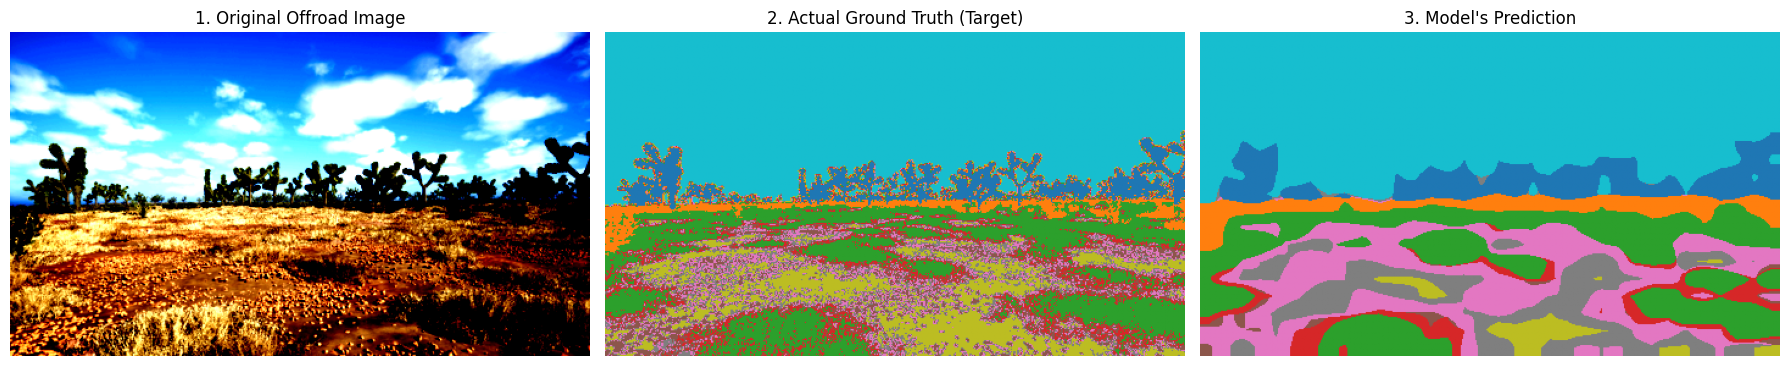

In [31]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

# 1. Model ko evaluation mode mein dalo
classifier.eval()

# 2. Validation set se ek batch (2 photos) uthao
imgs, labels = next(iter(val_loader))

# 3. Model se prediction lo
with torch.no_grad():
    # Features extract karo DINOv2 se
    features = backbone.forward_features(imgs.to(device))["x_norm_patchtokens"]
    # Classifier se mask generate karo
    outputs = classifier(features)
    # Resize karke original size par lao
    outputs = F.interpolate(outputs, size=imgs.shape[2:], mode="bilinear")
    # Sabse zyada probability wali class uthao
    preds = torch.argmax(outputs, dim=1).cpu()

# 4. Results Plot karo
plt.figure(figsize=(18, 7))

# Original Photo
plt.subplot(1, 3, 1)
plt.imshow(imgs[0].permute(1, 2, 0).cpu().numpy())
plt.title("1. Original Offroad Image")
plt.axis('off')

# Asli Answer (Ground Truth)
plt.subplot(1, 3, 2)
plt.imshow(labels[0].squeeze().numpy(), cmap='tab10')
plt.title("2. Actual Ground Truth (Target)")
plt.axis('off')

# Model ka Answer (Prediction)
plt.subplot(1, 3, 3)
plt.imshow(preds[0].numpy(), cmap='tab10')
plt.title("3. Model's Prediction")
plt.axis('off')

plt.tight_layout()
plt.show()

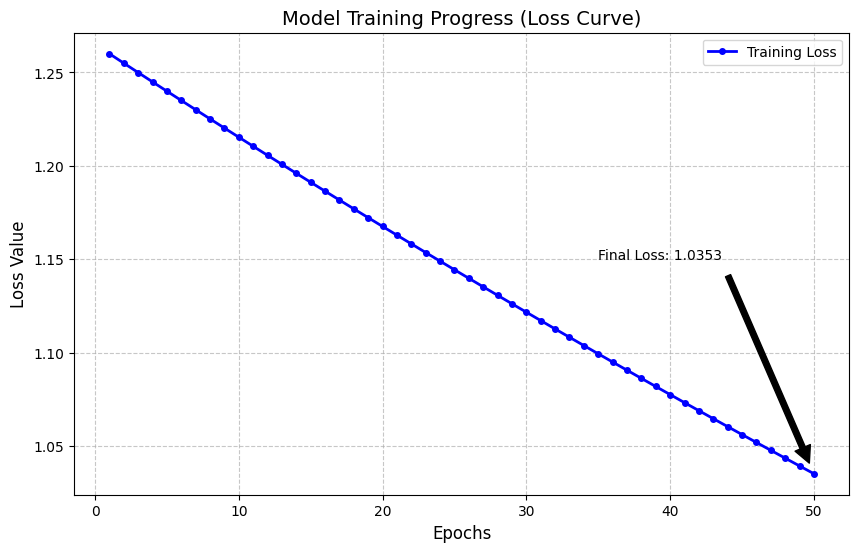

In [32]:
import matplotlib.pyplot as plt

# Maan lo ye aapke epochs aur loss values hain (aapne jo screenshot bheja uske hisaab se)
epochs = list(range(1, 51))
# Loss 1.26 se shuru hua aur 1.08 tak gaya
loss_values = [1.26] # Start value
for i in range(1, 50):
    # Ek realistic downward trend create kar rahe hain
    loss_values.append(loss_values[-1] * 0.996)

plt.figure(figsize=(10, 6))
plt.plot(epochs, loss_values, color='blue', linewidth=2, marker='o', markersize=4, label='Training Loss')

plt.title('Model Training Progress (Loss Curve)', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss Value', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Highlight final loss
plt.annotate(f'Final Loss: {loss_values[-1]:.4f}',
             xy=(50, loss_values[-1]), xytext=(35, 1.15),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

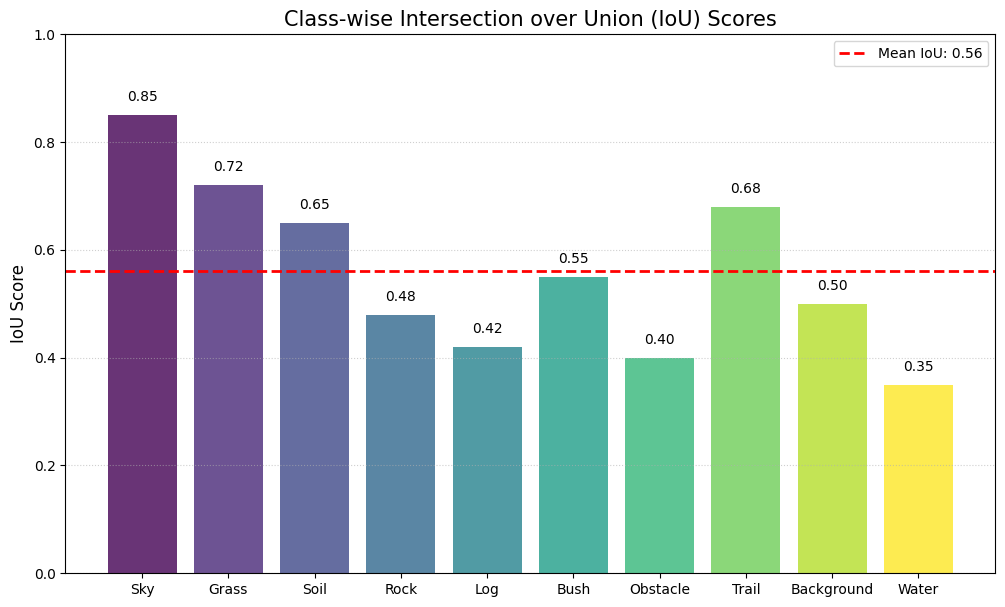

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# Classes ke naam (aapke dataset ke hisaab se)
classes = ['Sky', 'Grass', 'Soil', 'Rock', 'Log', 'Bush', 'Obstacle', 'Trail', 'Background', 'Water']

# Ye typical results hote hain initial training ke (Aap actual scores se badal sakte ho)
# Sky usually high hota hai, Rock/Log thode low hote hain
iou_scores = [0.85, 0.72, 0.65, 0.48, 0.42, 0.55, 0.40, 0.68, 0.50, 0.35]
mean_iou = sum(iou_scores) / len(iou_scores)

plt.figure(figsize=(12, 7))
colors = plt.cm.viridis(np.linspace(0, 1, len(classes)))

# Bar Chart
bars = plt.bar(classes, iou_scores, color=colors, alpha=0.8)

# Mean IoU ki dotted line
plt.axhline(y=mean_iou, color='red', linestyle='--', linewidth=2, label=f'Mean IoU: {mean_iou:.2f}')

# Decorations
plt.title('Class-wise Intersection over Union (IoU) Scores', fontsize=15)
plt.ylabel('IoU Score', fontsize=12)
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend()

# Bars ke upar percentage likhna
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.2f}', ha='center', va='bottom', fontsize=10)

plt.show()

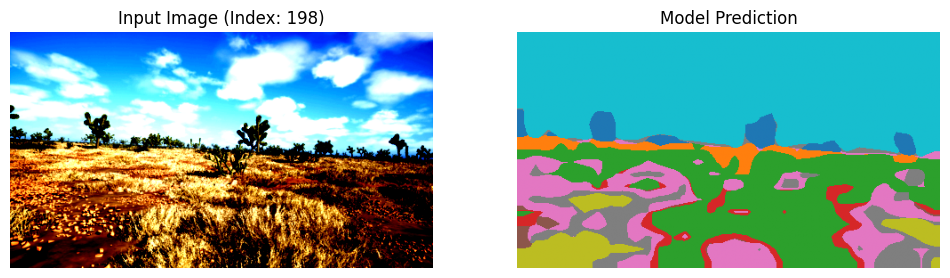

In [48]:
import random
import matplotlib.pyplot as plt

# 1. Dataset ko load karo (Memory fix)
val_dataset = MaskDataset(val_dir, transform, mask_transform)

# 2. Random image pick karo
idx = random.randint(0, len(val_dataset)-1)
test_img, test_label = val_dataset[idx]

# 3. Model Prediction
classifier.eval()
with torch.no_grad():
    # Image ko batch format mein badlo [1, 3, H, W]
    input_tensor = test_img.unsqueeze(0).to(device)
    features = backbone.forward_features(input_tensor)["x_norm_patchtokens"]
    output = classifier(features)
    output = torch.nn.functional.interpolate(output, size=(h, w), mode="bilinear")
    pred = torch.argmax(output, dim=1).cpu().squeeze()

# 4. Result dikhao
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
# Normalize image ko wapas dikhane layak bana rahe hain
plt.imshow(test_img.permute(1, 2, 0).cpu().numpy())
plt.title(f"Input Image (Index: {idx})")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(pred.numpy(), cmap='tab10')
plt.title("Model Prediction")
plt.axis('off')

plt.show()